# Tutorial: using STAIA package
This is an introduction to using the STAIA package: a package to lower the computational barrier in spatial transcriptomics by combining well-established packages into a single wrapper. Different modules have also been added that were missing in these modules. <br><br>
In this file, we'll walk through most of the steps that you are able to take in the pipeline. If you are wondering if there is more possible, please take a look at the documentation, which is publicly available: https://emmaevonk.github.io/STAIA/. <br><br>
This package is written for Xenium data (from 10X Genomics). If you have any suggestions on what is missing or what could be improve, contact Emma.<br><br>
Data for the tutorial can be downloaded from here: https://www.10xgenomics.com/datasets/xenium-ffpe-human-breast-biomarkers

## 1 Read data
The first step of the analysis is to read the data and import packages needed.
### 1.1 Import packages

In [ ]:
import STAIA

### 1.2 Read Data
Now the module is loaded and ready for use. First, load the data before all analyses can take place. When running `STAIA.read_data()` it returns a SpatialData object. The input can either be a zarr file or the Xenium output bundle.

In [2]:
path_to_bundle = "data"

sdata = STAIA.read_data(path_to_bundle)

# For analysis it's good to convert this to an AnnData object due to dimensionality and how this is handled by other modules.
adata = sdata.tables["table"]

/exports/archive/hg-funcgenom-research/evonk/conda/envs/analysis_xenium/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


There are some specific options you can use now:
<li>If you want to use a specific region of interest, call the `STAIA.roi()` function including the coordinates.</li>
<li>If you are using multinucleated data (e.g. muscle data), and want to add the information of the nuclei as well, please use the `STAIA.add_nuclei(sdata)` function. This returns a SpatialData object, which you can convert into an adata. An extra layer is added showing the geometry (coordinates) of all the nuclei. This is not taken into account with the other modules.</li>

## 2. Quality Contol (QC)
For the QC, STAIA makes use of [SpotSweeper; a tool for spatially aware quality control for spatial transcriptomics](https://pubmed.ncbi.nlm.nih.gov/38895212/). You don't have to call SpotSweeper yourself. To perform quality control, just follow the steps here in the notebook.

The column 'n_genes_by_counts' is not present in the data. Computing this column...
Column 'n_genes_by_counts' is computed. Generating visualizations...


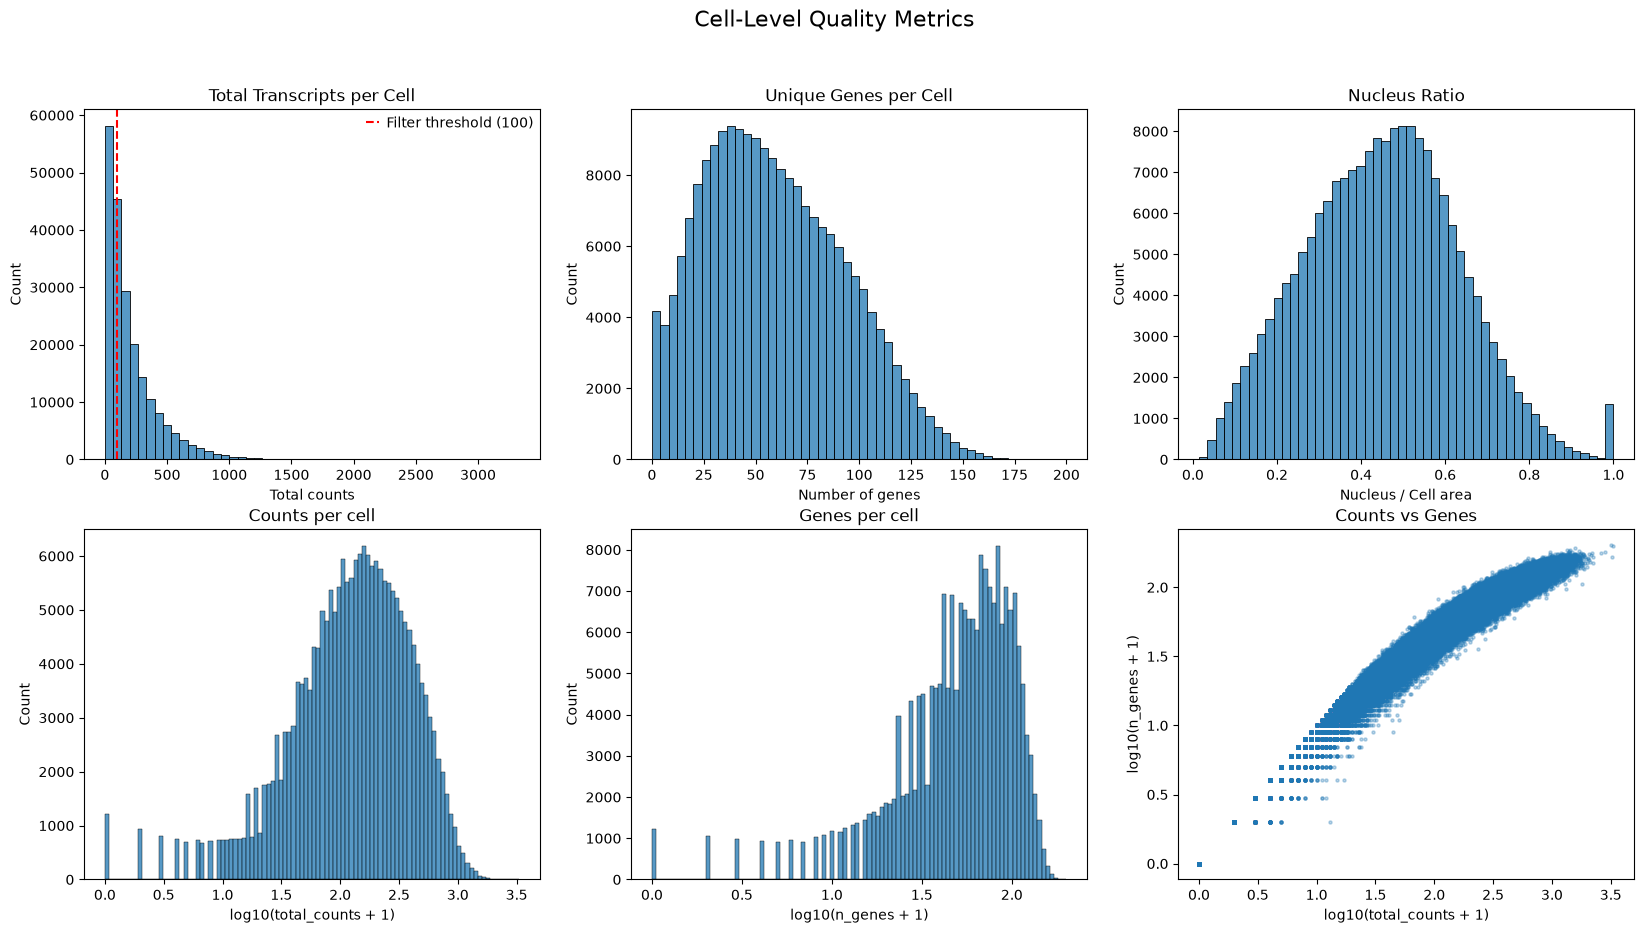

The distribution plots are saved in the current running directory: /exports/archive/hg-funcgenom-research/evonk/notebooks/STAIA_tutorial/cell_statistics.png


In [3]:
# Generate standardQC diagnostic plots
fig = STAIA.plot_qc_metrics(adata)

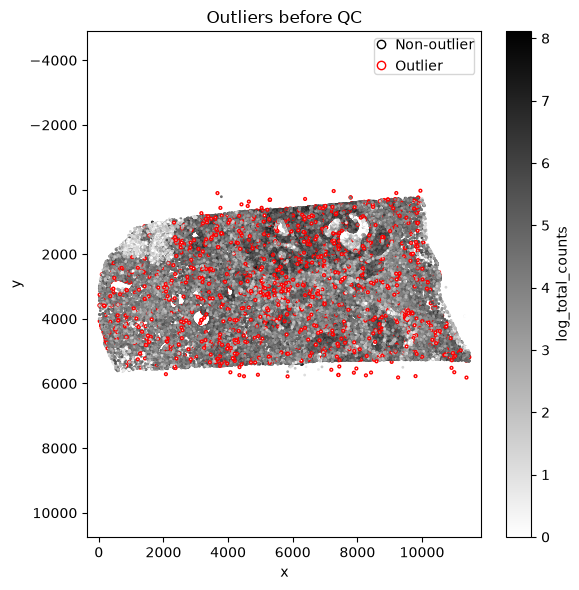

In [4]:
# plot the outliers in the data (based on SpotSweeper)
adata.obs['low_counts_outlier'] = STAIA.is_outlier(adata.obs['total_counts'], direction='lower')
adata = STAIA.detect_outlier(adata)
fig = STAIA.plot_outliers(adata,"region", metric = "log_total_counts", outliers="log_total_counts_outliers", title="Outliers before QC", legend=True, ring_overlay=False)

It is also possible to let STAIA recommend you thresholds. These are based on the  Median Absolute Deviation (MAD), which is calculated as: <br>
`MAD = median(|xi - median(x)|)` <br><br>
This measures the spread of the data around the median, but it is more robust to outliers than standard deviation (SD), which is why it's preferred for QC metrics that are often skewed.

In [5]:
thr = STAIA.recommend_threshold(adata)
print(thr)

{'min_genes': 5, 'max_genes': np.float64(130.0), 'min_counts': 10, 'max_counts': np.float32(415.0)}


If you don't agree with these recommended thresholds, feel free to change them by running this: <br>
```py
 thr = {
     "min_genes": a,
     "max_genes": b,
     "min_counts": c,
     "max_counts": d 
 }
```

In [6]:
# filter the data based on the thresholds
adata = STAIA.perform_quality_control(adata, thr)

Cells before filtering: 209467
Cells after filtering: 171914


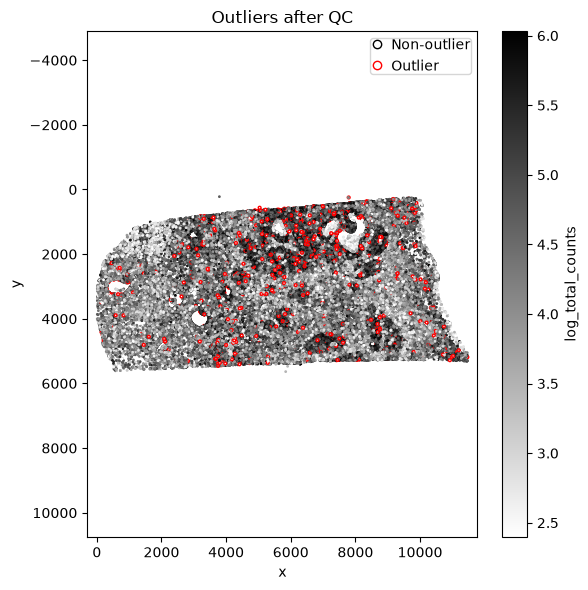

In [7]:
# check outliers in the data (again)
fig = STAIA.plot_outliers(adata,"region", metric = "log_total_counts", outliers="log_total_counts_outliers", title="Outliers after QC", legend=True, ring_overlay=False)

### 1.3 Normalizing data

In [8]:
# if you want to keep a copy of the raw counts in your anndata object:
adata.layers["raw_counts"] = adata.X.copy()

# you can either normalize the data by counts or size. For now, we'll do it by counts
adata = STAIA.counts_normalized(adata)

# this is how to normalize by size:
# adata = STAIA.size_normalization(sdata)

# saving the normalized counts in a separate layer
adata.layers["count_norm"]  = adata.X

## 2. Clustering

Computing Leiden clusters...


/exports/archive/hg-funcgenom-research/evonk/functionalAPI/STAIA/plot/_cluster.py:87: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=resolution, random_state=random_state)


Leiden clusters computed.


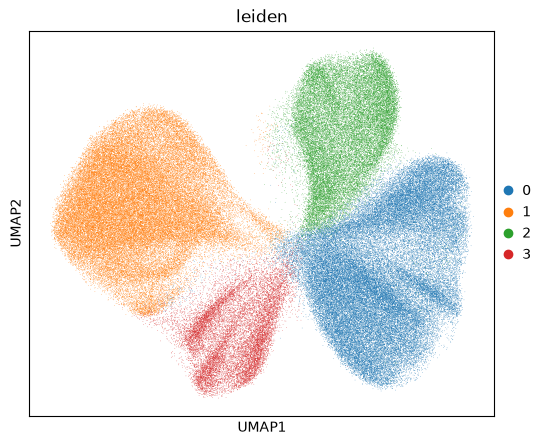

In [9]:
adata_cluster = STAIA.cluster(adata, colors=["leiden"])

The parameter `colors` can be anything, as long as it's present in the adata object. It should always be in list-format. Examples: segmentation_method, transcript_counts, nucleus_count, cell_area.

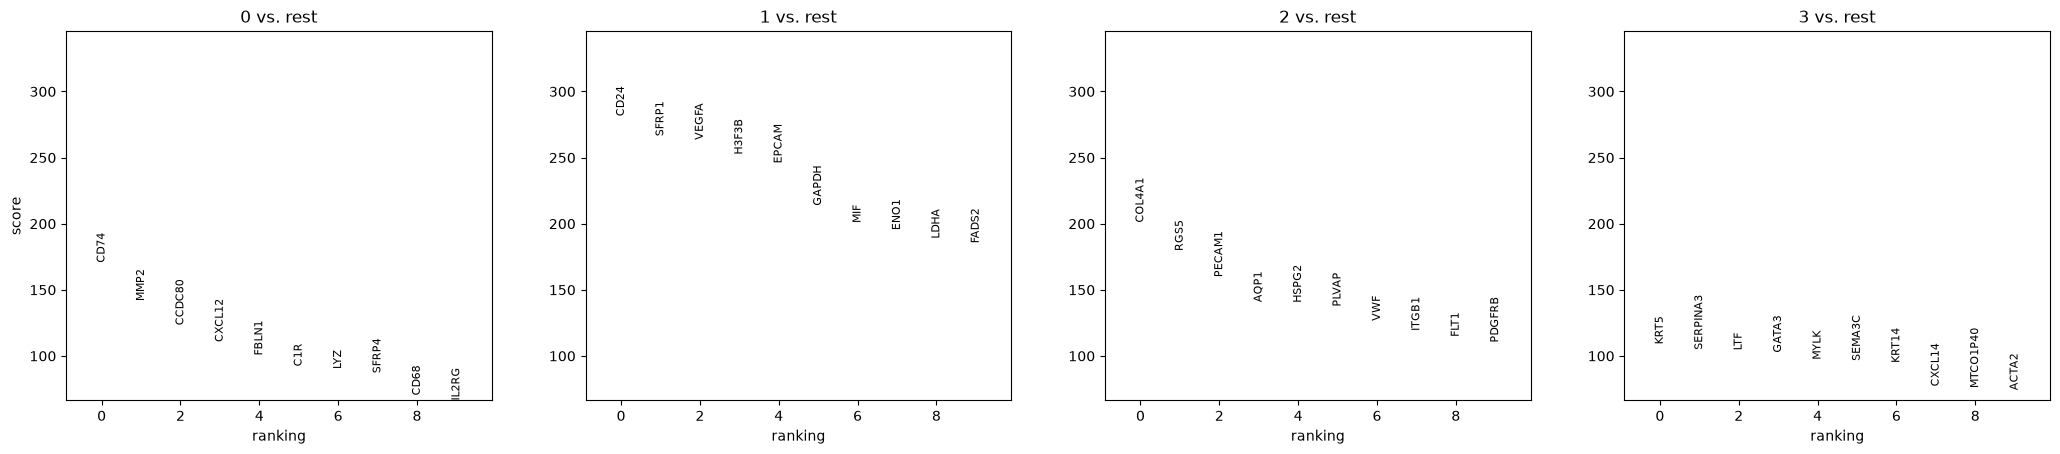

In [10]:
# you can rank the genes by groups
adata_ranked = STAIA.rank_genes_group(adata_cluster, res=0.5)

## 3. Assigning labels to samples
If you have multiple samples on a slides, it's possible to assign labels to them by using an algorithm called 'watershed segmentation'. This can be done using STAIA.

When running watershed segmentation it is import to know the possible parameters:<br>
<li><b>pixel_size_um:</b> the resolution of the intermediate grid used for segmentation, in micrometers per pixel. Smaller values give finer spatial detail but increase memory use and runtime; larger values are faster, but can cause nearbly samples to blur together. (default: 20)</li>
<li><b>blur_sigma:</b> the SD of a Gaussian smoothing filter applied to a density grid. Higher values smooth out more noise and small gaps, which helps connect fragmented regions within a sample, but too much smoothing can cause distinct samples to merge. (default: 3)</li>
<li><b>closing_radius:</b> controls a morphological closing step (dilation followed by erosion) applied to the binary mask. This fills small holes and gaps within a sample region. A larger radius fills bigger gaps but risks bridging two nearby samples (default: 5)</li>
<li><b>erosion_radius: </b>this is probably the most important tuning parameter. Before watershed runs, the mask is eroded by this amount to create seed regions. Larger values shrink the seeds more aggressively, which enforces stronger separation between nearby samples. If two samples keep merging into one, increasing this is the first thing to try. (default: 30)</li>
<li><b>min_cells:</b> the minimum amount of cells allowed per sample. (default: 500)</li>

<div style="border: 2px solid #336699; padding: 15px; border-radius: 8px;">
  <ol style="margin-top: 10px; padding-left: 25px; font-size: 17px; color: #e6d8d8ff;">
    In this data, one sample is present, so this module is not necessary. But, if you have multiple samples on a slide you can label them using this module.
  </ol>
</div>

Loaded 171,914 rows.
Grid: 574 x 272 px  (20 µm/px)
Seeds after erosion: 1
Components after watershed: 1

✓ 1 sample(s)  |  1,763 unassigned cells


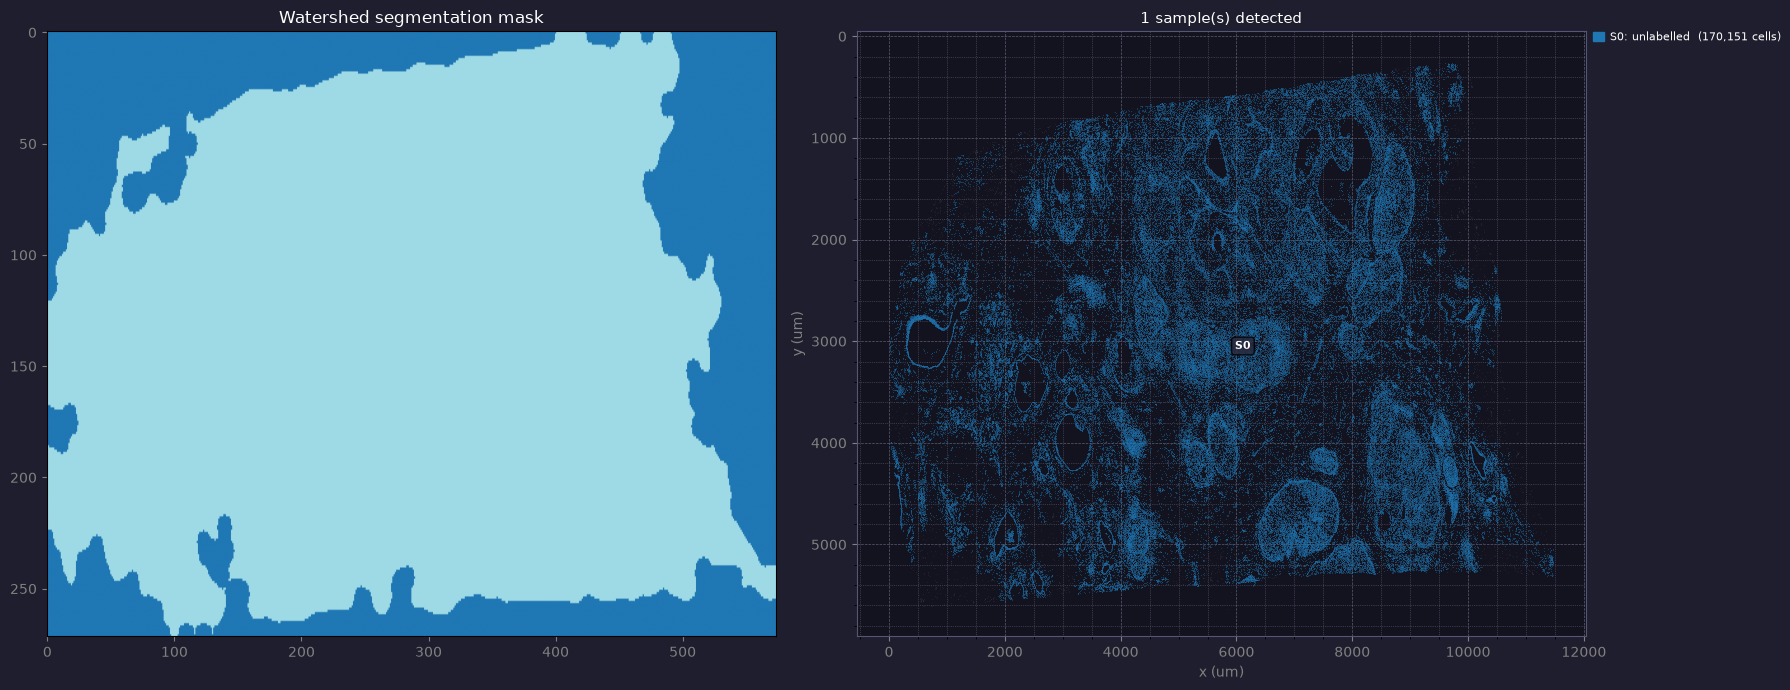

In [11]:
output_dir = "/exports/archive/hg-groep-spitali/Pietro/STAIA/MG_analysis"

# if the segmentation is not what you want, please use the parameters described above to refine.
df = STAIA.run_watershed(adata, output_dir=output_dir)

In [12]:
# show the grid and perform any manual splits if you want. Then click on 'save & export'
df_split_base = df.copy()
session = STAIA.SplitSession(df_split_base)
%matplotlib widget
session.show()

Output()

In [13]:
df_results, ids = session.result()

# pass to the labelling session (LabelSession)
label_session = STAIA.LabelSession(df_results, ids,adata=adata_ranked, output_dir=output_dir)
%matplotlib widget
label_session.show()

# perform label assignment
conditions = label_session.result()

# Press on 'Save & Export' when labelling is finished

Output()

In [14]:
adata_ranked.obs.head()

,cell_id,transcript_counts,control_probe_counts,genomic_control_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,cell_area,nucleus_area,...,low_counts_outlier,log_total_counts,log_total_counts_z,log_total_counts_outliers,log1p_n_genes_by_counts,log1p_total_counts,density,leiden,x_centroid,y_centroid
0,aaaafije-1,17,0,0,0,0,0,17.0,28.990314,13.727500,...,False,2.890372,-2.122709,False,2.708050,2.890372,0.586403,0,17.800020,3305.250732
1,aaaajeep-1,10,0,0,0,0,0,10.0,28.448439,13.908126,...,False,2.397895,-2.720593,False,2.197225,2.397895,0.351513,0,21.648016,3251.783936
2,aaaapjim-1,88,0,0,0,0,0,88.0,63.670315,34.680001,...,False,4.488636,-0.176166,False,3.688879,4.488636,1.382120,0,21.587891,3312.855957
3,aaabcmin-1,110,0,0,0,0,0,110.0,90.538285,65.386252,...,False,4.709530,0.027791,False,4.043051,4.709530,1.214956,0,76.031601,3368.481689
4,aaabmnja-1,108,0,0,0,0,0,108.0,55.226096,43.801564,...,False,4.691348,0.118757,False,3.784190,4.691348,1.955597,0,62.798439,3291.045654


## 4. Analysis 

In [15]:
%matplotlib inline

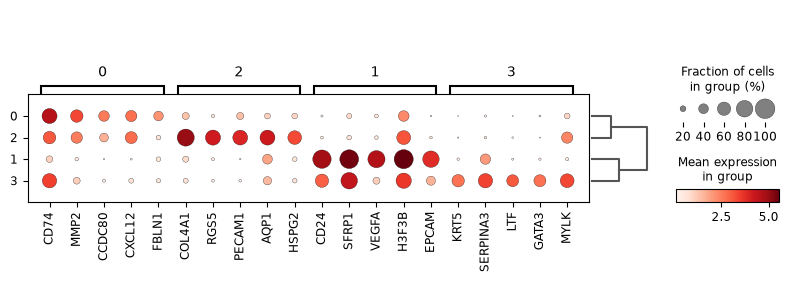

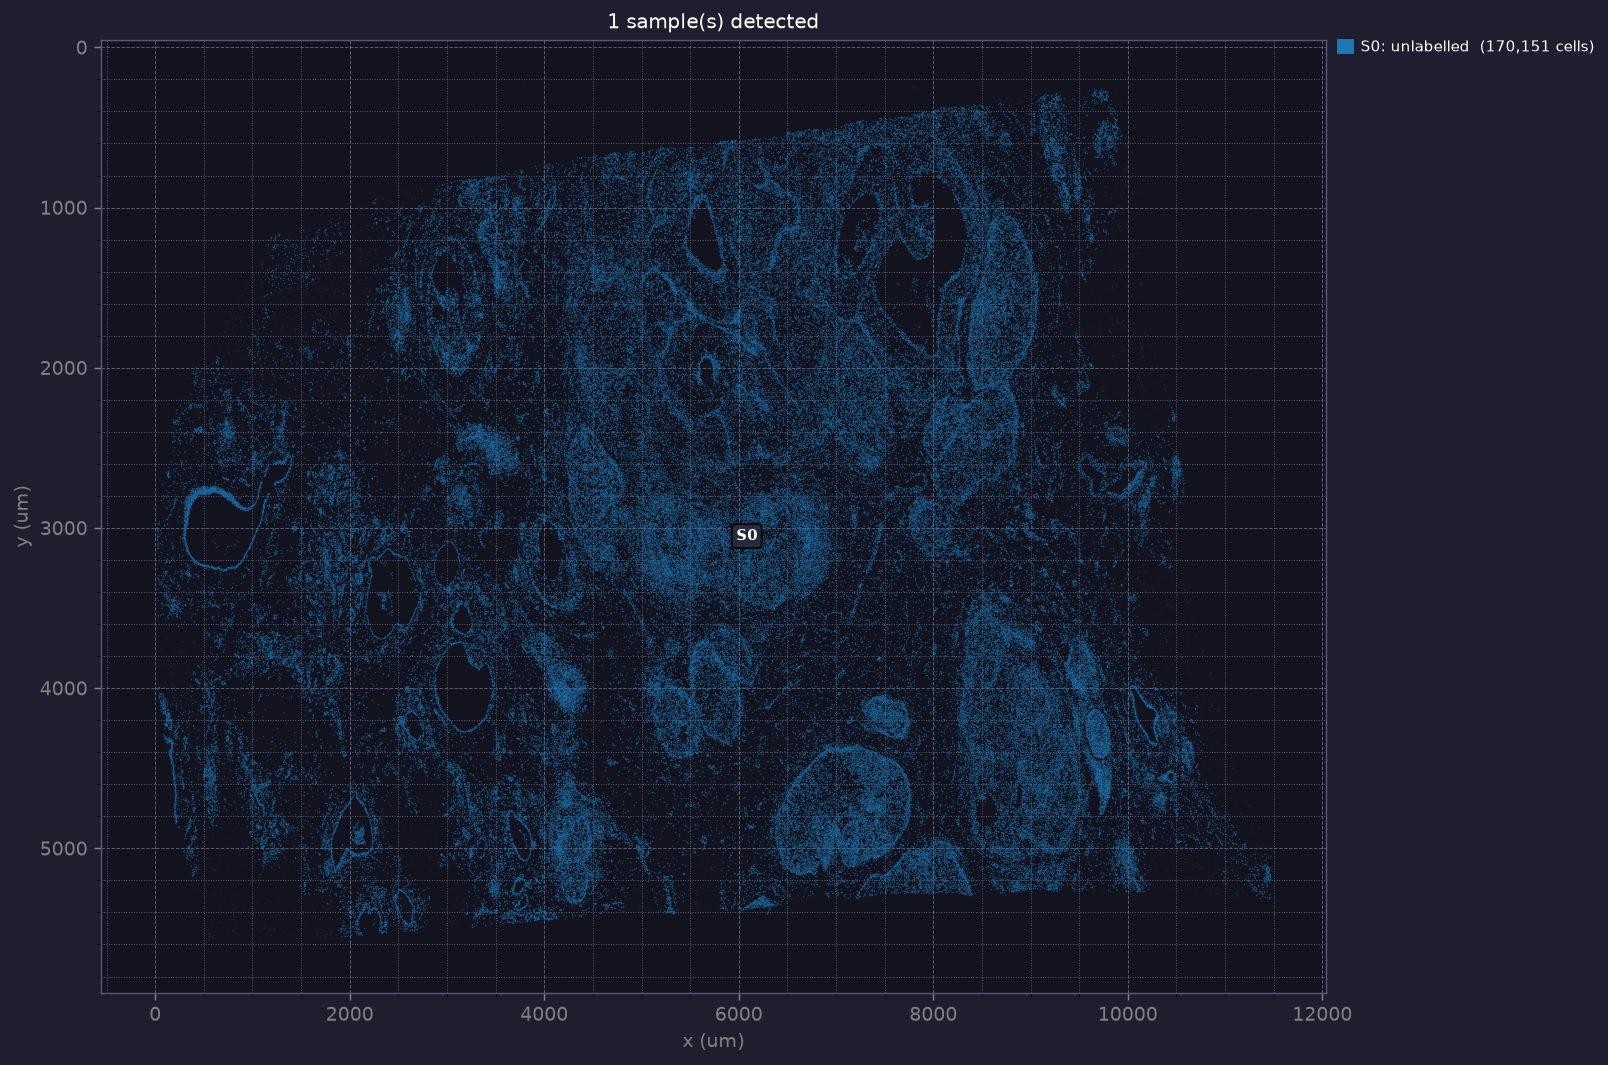

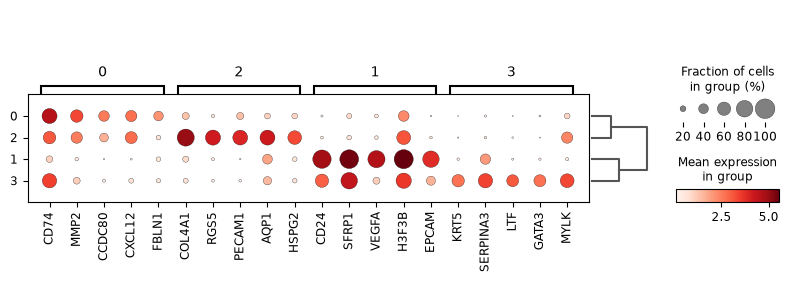

In [16]:
STAIA.dotplot(adata_ranked)

If the data is annotated, it might be interesting to look at cell type composition by running this:
```py
    STAIA.celltype_composition(adata)
```
It is also possible to plot the Xenium slide, showing colored data points by gene expression (or meta data).

/exports/archive/hg-funcgenom-research/evonk/conda/envs/analysis_xenium/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


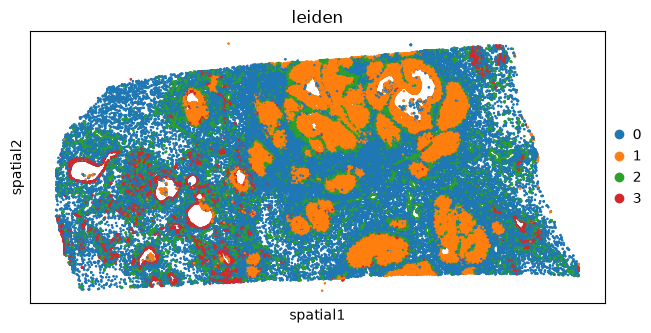

In [17]:
STAIA.plot_image(adata_ranked)

We now compute and visualize the neighborhood enrichment between clusters using STAIA. Neighborhood enrichment quantifies whether cells from specific clusters are found in spatial proximity more or less often than expected by chance. This function computes enrichment statistics using [squidpy](https://squidpy.readthedocs.io/en/stable/) and generates a heatmap visualization.

  0%|          | 0/1000 [00:00<?, ?/s]

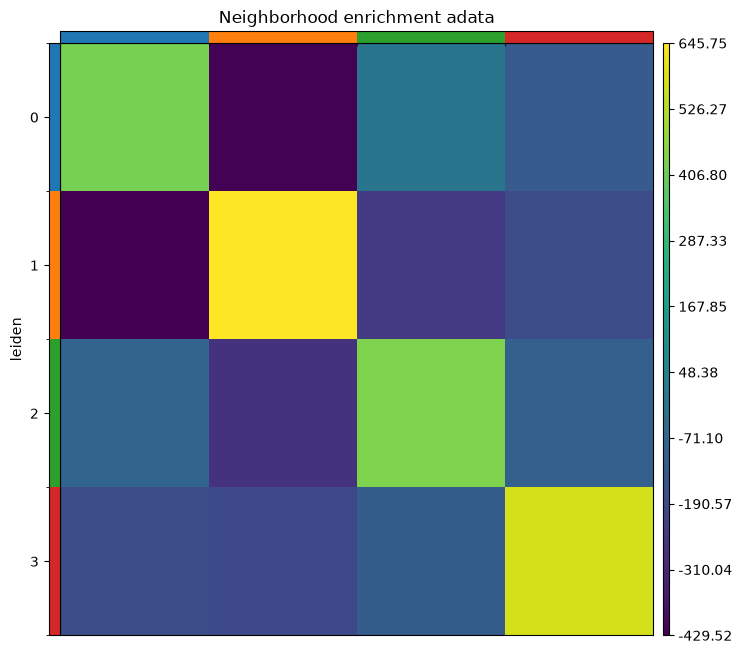

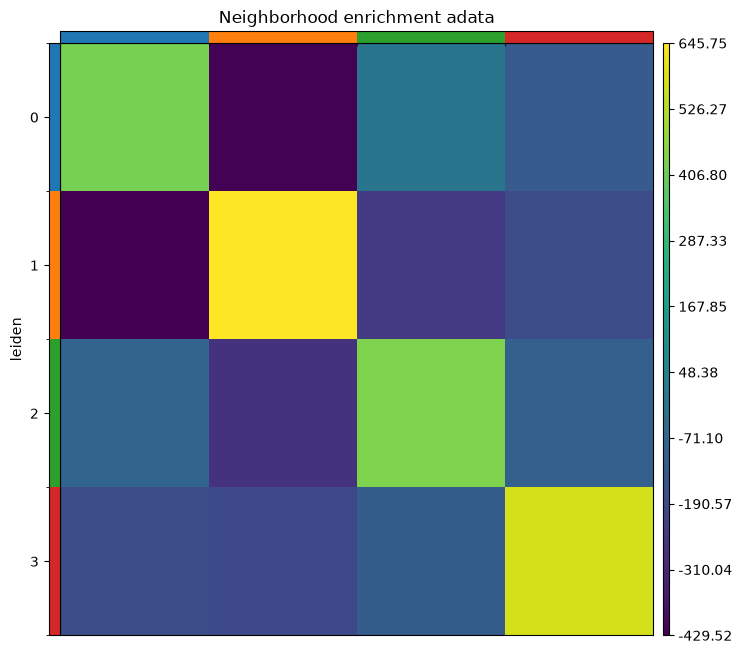

In [18]:
STAIA.nhood_enrichment(adata_ranked)

## 5. Spatial Clustering
There are three ways to perform spatial clustering in STAIA: with [BANKSY](https://www.nature.com/articles/s41588-024-01664-3), with [NicheCompass](https://www.nature.com/articles/s41588-025-02120-6), or with [CellCharter](https://cellcharter.readthedocs.io/en/latest/).
We'll walk through all 3, starting with performing spatial clustering with BANKSY.

### 5.1 BANKSY
There are 2 assumptions when running BANKSY:
<li>The data is already log normalized (either by size or counts. We already did that here).</li>
<li>Data is already filtered (we already QC'd)<li>

Please note that running BANKSY can take a while.

In [19]:
# STAIA.run_banksy(adata_ranked)

### 5.2 NicheCompass

In [20]:
# first build a gp dict if you don't have any
# STAIA.save_gp_dict()

In [21]:
# run full nichcompass pipeline (training included, if this is already done, run `STAIA.niche_analysis_load()` instead). It expects multiple samples (labeled by column 'sample')
# adata.obs["sample"] = 1
# STAIA.niche_analysis_train(adata, gp_dict_path='/exports/archive/hg-funcgenom-research/evonk/notebooks/STAIA_tutorial/gp_dict/combined_gp_dict.json', n_epochs=2)

### 5.3 CellCharter
When running cellcharter, you can first check the stability of the clusters and determine the clusters this way:

[rank: 0] Seed set to 12345
[rank: 0] Seed set to 12345
[rank: 0] Seed set to 12345
[rank: 0] Seed set to 12345
/exports/archive/hg-funcgenom-research/evonk/conda/envs/analysis_xenium/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.X does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


Start training model. This can take a while. Do not stop the code while running...


GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
/exports/archive/hg-funcgenom-research/evonk/conda/envs/analysis_xenium/lib/python3.11/site-packages/lightning/pytorch/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Training:   0%|          | 0/25 [00:00<?, ?it/s]

/exports/archive/hg-funcgenom-research/evonk/conda/envs/analysis_xenium/lib/python3.11/site-packages/scvi/module/_vae.py:573: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)
/exports/archive/hg-funcgenom-research/evonk/conda/envs/analysis_xenium/lib/python3.11/site-packages/scvi/module/_vae.py:573: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)
/exports/archive/hg-funcgenom-research/evonk/conda/envs/analysis_xenium/lib/python3.11/site-packages/scvi/module/_vae.py:573: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)
/exports/archive/hg-funcgenom-research/evonk/conda/envs/analysis_xenium/lib/python3.11/site-packages/scvi/module/_vae.py:573: UserWarning: The value argum

...

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/exports/archive/hg-funcgeno

Output()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
SLURM auto-requeueing enabled. Setting signal handlers.


Output()

Written the spatial clusters found by CellCharter to 'adata_with_spatial_domains.h5ad'


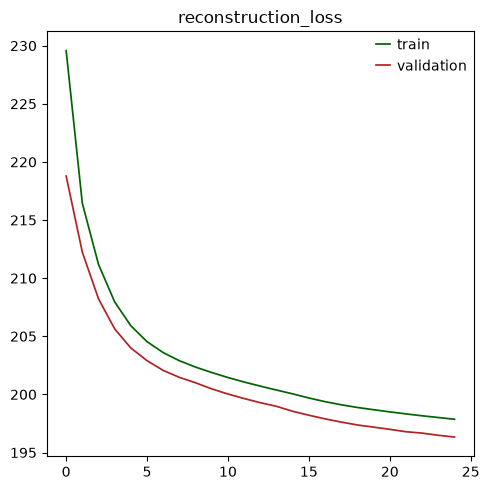

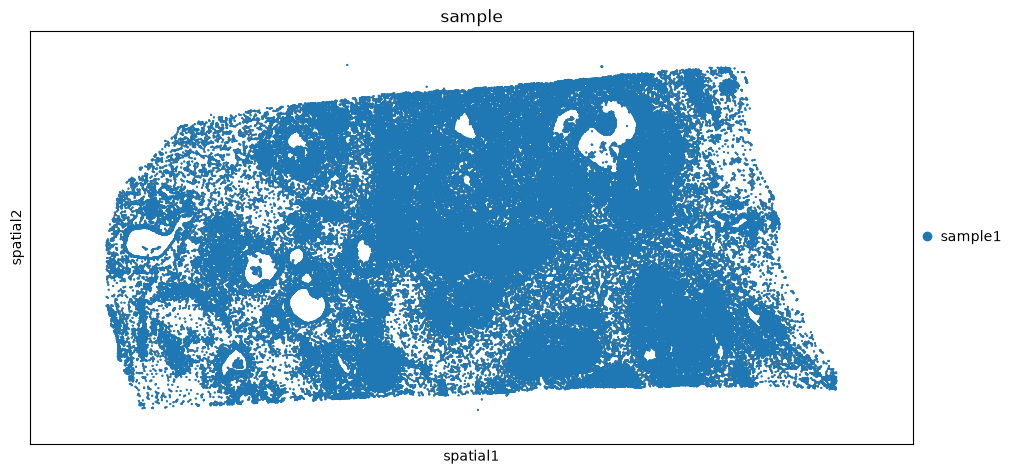

In [22]:
# run cellcharter
# STAIA.run_cellcharter(adata_ranked, epoch=25)
adata.obs["sample"] = 'sample1'
adata.obs['sample'] = adata.obs['sample'].astype('category')
STAIA.run_cellcharter(adata, epoch=25)

## 6. Pseudobulk DE analysis
There are 2 different ways to run pseudobulk DE analysis:<br>
<li>`pseudobulk` function for target single cell-type comparison, and</li>
<li>`pseudobulk_per_condition` function that is a high-level wrapper that calls `pseudobulk` repeatedly to sweep across all condition pairs and all cell types automatically.</li>
<br><br>
<div style="border: 2px solid #336699; padding: 15px; border-radius: 8px;">
  <ol style="margin-top: 10px; padding-left: 25px; font-size: 17px; color: #b11919ff;">
    It is important to know that cell types most be present in the data to run pseudobulk analysis.
  </ol>
</div>

In [24]:
adata

AnnData object with n_obs × n_vars = 171914 × 280
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels', 'n_genes_by_counts', 'low_counts_outlier', 'log_total_counts', 'log_total_counts_z', 'log_total_counts_outliers', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'density', 'leiden', 'x_centroid', 'y_centroid', 'sample', '_scvi_batch', '_scvi_labels', 'spatial_domain'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_mean_counts', 'log1p_total_counts'
    uns: 'spatialdata_attrs', 'log1p', 'pca', 'neighbors', 'leiden', 'umap', 'leiden_colors', 'rank_genes_groups', 'dendrogram_leiden', 'spatial_neighbors', 'leiden_nhood_enrichment', '_scvi_uuid', '_scvi_manager_u

In [23]:
# You need cell types to run this.
sig_genes = STAIA.pseudobulk(
    adata,
    celltype="celltype",
    cond=["WT", "TEST"],
    sample_col="sample_id",
    treatment_col="condition",
    celltype_col="cell_type",
    save=True
)

KeyError: 'cell_type'

In [ ]:
all_results = STAIA.pseudobulk_per_condition(
    adata,
    all_conditions=["WT", "TEST", "TREATED"],
    label_col="condition",
    sample_id="sample_id",
    celltype_col="leiden" # could also be the real celltype column
)

# the results are a nested dictionary: {(cell_type, "condA_vs_condB"): DataFrames}

And that's it! That's all the analysis steps that STAIA can perform now. If you are missing anything, please let me know, so I can see if it can be integrated as well.